In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

/Users/abhinavsarkar/Documents/Projects/Langgraph/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/abhinavsarkar/Documents/Projects/Langgraph/venv/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [20]:
#declare state of batsman in a match
class BatsmanState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int 

    sr: float
    bpb: float
    boundary_rate: float
    summary: str


In [21]:
#function for nodes

def calc_sr(state: BatsmanState) -> BatsmanState:
    state['sr'] = (state['runs'] / state['balls']) * 100
    return {'sr': state['sr']}

def calc_bpb(state: BatsmanState) -> BatsmanState:
    state['bpb'] = state['runs'] / state['balls']
    return {'bpb': state['bpb']}

def calc_boundary_rate(state: BatsmanState) -> BatsmanState:    
    state['boundary_rate'] = (state['fours'] + state['sixes']) / state['balls']
    return {'boundary_rate': state['boundary_rate']}

def summary(state: BatsmanState) -> str:
    summary =  f"Runs: {state['runs']}, Balls: {state['balls']}, Fours: {state['fours']}, Sixes: {state['sixes']}, SR: {state['sr']:.2f}, BPB: {state['bpb']:.2f}, Boundary Rate: {state['boundary_rate']:.4f}"
    state[summary] = summary
    return {'summary': summary}

In [22]:
#create nodes for the graph

graph = StateGraph(BatsmanState)

graph.add_node('calc_sr', calc_sr)
graph.add_node('calc_bpb', calc_bpb)
graph.add_node('calc_boundary_rate', calc_boundary_rate)
graph.add_node('summary', summary)

In [23]:
#create edges for the graph

graph.add_edge(START, 'calc_sr')
graph.add_edge(START, 'calc_bpb')
graph.add_edge(START, 'calc_boundary_rate')

graph.add_edge('calc_sr', 'summary')
graph.add_edge('calc_bpb', 'summary')
graph.add_edge('calc_boundary_rate', 'summary')

graph.add_edge('summary', END)

In [24]:
workflow = graph.compile()

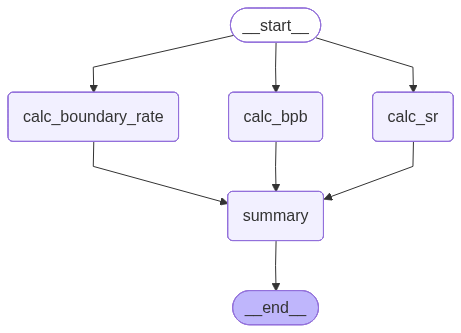

In [25]:
workflow 

In [26]:
inital_state = BatsmanState(runs=120, balls=80, fours=10, sixes=5)

final_state = workflow.invoke(inital_state)
 
print(final_state)

{'runs': 120, 'balls': 80, 'fours': 10, 'sixes': 5, 'sr': 150.0, 'bpb': 1.5, 'boundary_rate': 0.1875, 'summary': 'Runs: 120, Balls: 80, Fours: 10, Sixes: 5, SR: 150.00, BPB: 1.50, Boundary Rate: 0.1875'}
